In [1]:
# model_dict = {
#     # "BERTimbau Base": "neuralmind/bert-base-portuguese-cased",
#     # "BERT Multilingual Base Cased": "bert-base-multilingual-cased",
#     # # "BioBERTpt": "pucpr/biobertpt-all", # Muito grande, não roda na minha máquina
#     # # "BERTimbau Large": "neuralmind/bert-large-portuguese-cased",  # Muito grande, não roda na minha máquina
#     "GPorTuguese-2": "pierreguillou/gpt2-small-portuguese",
#     "GPT2-BioPt": "pucpr/gpt2-bio-pt",
# }
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import csv

from datasets import Dataset, features

from llm_mri import ActivationAreas, Evaluation
from llm_mri.dimensionality_reduction import PCA, UMAP, SVD


# Get Graphs

In [2]:
RAW_DATASET_PATH = "../probing/data/raw/"
INTERIM_DATASET_PATH = "../probing/data/interim/"
PROCESSED_DATASET_PATH = "../probing/data/processed/"
GRAPH_PATH = f"{INTERIM_DATASET_PATH}graphs/"
COMPLETE_GRAPH_PATH = f"{GRAPH_PATH}complete/"
FILTERED_GRAPH_PATH = f"{GRAPH_PATH}filtered/"
GRID_SIZES = [10, 50]

In [3]:
exps_dict = {
    "medical_answers_dpoc": {
        "datapath": "../datasets/medical_answers/dpoc_hf_dataset",
        "models": [
            "neuralmind/bert-base-portuguese-cased",
            "bert-base-multilingual-cased",
            "pucpr/biobertpt-all",  # Muito grande, não roda na minha máquina
            "neuralmind/bert-large-portuguese-cased",  # Muito grande, não roda na minha máquina
            "distilbert/distilbert-base-multilingual-cased",
        ],
        "labels": ["top", "bottom"],
    },
    "medical_answers_iam": {
        "datapath": "../datasets/medical_answers/iam_hf_dataset",
        "models": [
            "neuralmind/bert-base-portuguese-cased",
            "bert-base-multilingual-cased",
            "pucpr/biobertpt-all",  # Muito grande, não roda na minha máquina
            "neuralmind/bert-large-portuguese-cased",  # Muito grande, não roda na minha máquina
            "distilbert/distilbert-base-multilingual-cased",
        ],
        "labels": ["top", "bottom"],
    },
    "odd_man_out_2_000": {
        "datapath": "../probing/data/raw/odd_man_out_2_000.txt",
        "models": ["bert-base-uncased", "bert-large-uncased"],
        "labels": ["O", "C"],
    },
}

In [4]:
from datasets import load_from_disk

def get_data(data_name, data_path):
  if "medical_answers" in data_name :

    data = load_from_disk(data_path)
    data.cleanup_cache_files()
    return data
  
  elif "odd_man_out" in data_name:
    df = pd.read_csv(
        data_path,
        sep="\t",
        names=["split", "label", "text"],
        quoting=csv.QUOTE_NONE
    )

    # 2. Filtrar apenas o que você deseja (ex: apenas o split de treino 'tr')
    df = df.drop(columns=["split"])

    # 3. Criar o Dataset do Hugging Face (como feito no notebook Emotions.ipynb)
    dataset = Dataset.from_pandas(df.reset_index(drop=True))

    # 4. Mapear as labels para ClassLabel (essencial para o LLM-MRI)
    class_names = [str(x) for x in sorted(dataset.unique("label"))]
    class_feature = features.ClassLabel(names=class_names)
    dataset = dataset.map(lambda x: {"label": class_feature.str2int(str(x["label"]))})
    dataset = dataset.cast(
        features.Features({"label": class_feature, "text": dataset.features["text"]})
    )
    return dataset

In [ ]:
for grid_size in [10, 50]:
    for task, info in exps_dict.items():
        data = get_data(task, info["datapath"])

        for model in info["models"]:

            print(f"Processing {model} on {task} on {grid_size}...")

            umap = UMAP(n_components=2, random_state=42, gridsize=grid_size)
            llm_mri_10 = ActivationAreas(
                model=model, device="cpu", dataset=data, reduction_method=umap
            )
            llm_mri_10.process_activation_areas(
                # save_raw_path="data/dados_hf_brutos",
                # save_reduced_path="data/reduzidos.pt",
                # save_jsonl_path=f"{INTERIM_DATASET_PATH}/{dataset_name}_features.json"
            )

            for label in info["labels"]:
                current_graph = llm_mri_10.get_graph(label)
                nx.write_gexf(
                    current_graph, f"data/graphs/{grid_size}/g_{model.split('/')[-1]}_{task}_{label}.gexf"
                )

            total_graph = llm_mri_10.get_graph(info["labels"])
            nx.write_gexf(total_graph, f"data/graphs/{grid_size}/g_{model.split('/')[-1]}_{task}_total.gexf")

# Number of nodes per layer for different models

In [5]:
from functools import partial

def get_layer_number(node_name):
    return int(node_name.split("_")[0])

# Each cell represents an activation region, in the format hiddenstate_x_y
def get_x_coord(node_name):
    return int(node_name.split("_")[1])

def get_y_coord(node_name):
    return int(node_name.split("_")[2])

def get_edge_name(source, target):
    source_layer = get_layer_number(source)
    target_layer = get_layer_number(target)
    
    if source_layer < target_layer:
        return f"{source_layer}>>{target_layer}"
    return f"{target_layer}>>{source_layer}"

def merge_data_from_dicts(d1, d2):
    all_keys = d1.keys() | d2.keys()

    d2_value_type = type(list(d2.values())[0])
    if d2_value_type is list:
        return {k: [*d1.get(k, []), *d2.get(k, [])] for k in all_keys}
    
    return {k: [*d1.get(k, []), d2.get(k, 0)] for k in all_keys}


def get_degree_per_layer(graph, return_mean=True):
    degree_per_layer = dict()
    current_graph_degree = graph.degree()
    for node, degree in current_graph_degree:
        layer = get_layer_number(node)
        if layer in degree_per_layer:
            degree_per_layer[layer].append(degree)
        else:
            degree_per_layer[layer] = [degree]
    if return_mean:
        degree_per_layer = {k: np.mean(v) for k, v in degree_per_layer.items()}
    return degree_per_layer

def get_num_nodes_per_layer(graph):
    nodes_per_layer = dict()
    for node in graph.nodes():
        layer = get_layer_number(node)
        if layer in nodes_per_layer:
            nodes_per_layer[layer] += 1
        else:
            nodes_per_layer[layer] = 1
    return nodes_per_layer

def get_num_edges_per_layer(graph):
    edges_per_layer = dict()
    for source, target in graph.edges():
        edge_name = get_edge_name(source, target)
        if edge_name in edges_per_layer:
            edges_per_layer[edge_name] += 1
        else:
            edges_per_layer[edge_name] = 1
    return edges_per_layer

def get_node_betweenness_per_layer(graph, normalized=True, return_mean=True):
    betweenness_per_layer = dict()

    general_betweenness = nx.betweenness_centrality(graph, normalized=normalized)
    for node, betweenness in general_betweenness.items():
        layer = get_layer_number(node)
        if layer in betweenness_per_layer:
            betweenness_per_layer[layer].append(betweenness)
        else:
            betweenness_per_layer[layer] = [betweenness]

    if return_mean:
        betweenness_per_layer = {k: np.mean(v) for k, v in betweenness_per_layer.items()}
    return betweenness_per_layer

def get_edge_betweenness_per_layer(graph, normalized=True, return_mean=True):
    betweenness_per_layer = dict()

    general_betweenness = nx.edge_betweenness_centrality(graph, normalized=normalized)
    for (source, target), betweenness in general_betweenness.items():
        layer = get_edge_name(source, target)
        if layer in betweenness_per_layer:
            betweenness_per_layer[layer].append(betweenness)
        else:
            betweenness_per_layer[layer] = [betweenness]

    if return_mean:
        betweenness_per_layer = {k: np.mean(v) for k, v in betweenness_per_layer.items()}
    return betweenness_per_layer

def get_node_strength_per_layer(graph, return_mean=True):
    strength_per_layer = dict()

    general_strength = graph.degree(weight='weight')
    for node, strength in general_strength:
        layer = get_layer_number(node)
        if layer in strength_per_layer:
            strength_per_layer[layer].append(strength)
        else:
            strength_per_layer[layer] = [strength]

    if return_mean:
        strength_per_layer = {k: np.mean(v) for k, v in strength_per_layer.items()}
    return strength_per_layer

def get_assortativity_per_layer(graph, return_mean=True):
    pass

def get_average_neighbor_degree_per_layer(graph, return_mean=True):
    avg_neighbor_degree_per_layer = dict()

    general_avg_neighbor_degree = nx.average_neighbor_degree(graph,  weight='weight')
    for node, avg_neighbor_degree in general_avg_neighbor_degree.items():
        layer = get_layer_number(node)
        if layer in avg_neighbor_degree_per_layer:
            avg_neighbor_degree_per_layer[layer].append(avg_neighbor_degree)
        else:
            avg_neighbor_degree_per_layer[layer] = [avg_neighbor_degree]

    if return_mean:
        avg_neighbor_degree_per_layer = {k: np.mean(v) for k, v in avg_neighbor_degree_per_layer.items()}
    return avg_neighbor_degree_per_layer

# https://www.notion.so/Centro-de-Massa-por-Camada-31ab046f0c2080998336d06c6f9f4d2c?source=copy_link
def get_center_of_mass_per_layer(graph, axl):
    # Formato: {camada: {"soma_massa_posicao": 0.0, "soma_massa": 0.0}}
    layer_accumulators = dict()

    # Seleciona a função correta de coordenadas com base no eixo ('x' ou 'y')
    pos_func = {"x": get_x_coord, "y": get_y_coord}[axl]
    
    general_strength = graph.degree(weight='weight')
    for node, strength in general_strength:
        pos = pos_func(node)
        layer = get_layer_number(node)
        
        if layer not in layer_accumulators:
            layer_accumulators[layer] = {"sum_mass_pos": 0.0, "sum_mass": 0.0}
        layer_accumulators[layer]["sum_mass_pos"] += (strength * pos)
        layer_accumulators[layer]["sum_mass"] += strength

    center_of_mass_per_layer = dict()
    
    for layer, data in layer_accumulators.items():
        if data["sum_mass"] > 0:
            cm = data["sum_mass_pos"] / data["sum_mass"]
        else:
            cm = 0.0
            
        center_of_mass_per_layer[layer] = cm
        
    return center_of_mass_per_layer



def get_metric_function(metric_name=None):
    metric_name_dict = {
        # "degree_per_layer": get_degree_per_layer,
        "num_nodes_per_layer": get_num_nodes_per_layer,
        "num_edges_per_layer": get_num_edges_per_layer,
        # "node_betweenness_per_layer": get_node_betweenness_per_layer,
        # "edge_betweenness_per_layer": get_edge_betweenness_per_layer,
        # "node_strength_per_layer":get_node_strength_per_layer,
        # # TODO: implementar a assortatividade de duas a duas camadas
        # # "assortativity_per_layer": get_assortativity_per_layer,
        # "average_neighbor_degree": get_average_neighbor_degree_per_layer,
        # "center_of_mass_x": partial(get_center_of_mass_per_layer, axl="x"),
        # "center_of_mass_y": partial(get_center_of_mass_per_layer, axl="y"),
    }
    if metric_name is None:
        return metric_name_dict
    return metric_name_dict.get(metric_name)
    

In [9]:
def dict_to_dataframe(metrics_per_layer_dict):
  # Separando métricas por nó e por aresta
  node_metrics = {k: v for k, v in metrics_per_layer_dict.items() 
                  if 'edge' not in k}
  edge_metrics = {k: v for k, v in metrics_per_layer_dict.items() 
                  if 'edge' in k}

  # DataFrame de métricas por camada (nó)
  df_nodes = pd.DataFrame(node_metrics)
  df_nodes.index.name = 'layer'
  df_nodes = df_nodes.reset_index()

  # DataFrame de métricas por aresta entre camadas
  df_edges = pd.DataFrame(edge_metrics)
  df_edges.index.name = 'layer_pair'
  df_edges = df_edges.reset_index()

  # Extrair a camada inicial e criar identificador
  df_edges['layer'] = df_edges['layer_pair'].apply(lambda x: int(x.split('>>')[0]))

  # Renomear colunas de arestas
  edge_cols = {col: f'edge_{col}' for col in df_edges.columns if col != 'layer' and col != 'layer_pair'}
  df_edges = df_edges.rename(columns=edge_cols)

  # Fazer merge apenas mantendo layer e layer_pair
  df_combined = pd.merge(df_nodes, df_edges[['layer', 'layer_pair'] + list(edge_cols.values())], 
                        on='layer', how='left')

  # Criar coluna de descrição
  df_combined.insert(1, 'layer_description', 
                    df_combined.apply(lambda row: f"{row['layer']} ({row['layer_pair']})" 
                                      if pd.notna(row['layer_pair']) else str(row['layer']), axis=1))

  # Remover layer_pair se quiser
  return df_combined.drop('layer_pair', axis=1)

In [10]:
for grid_size in GRID_SIZES:
    for task, info in exps_dict.items():
        data = get_data(task, info["datapath"])

        for model in info["models"]:
            for label in [*info["labels"], "total"]:

                metrics_per_layer = dict()

                for metric_name, metric_func in get_metric_function().items():
                    current_graph = nx.read_gexf(
                        f"data/graphs/{grid_size}/g_{model.split('/')[-1]}_{task}_{label}.gexf"
                    )

                    metrics_per_layer[metric_name] = metric_func(current_graph)

                df_metrics = dict_to_dataframe(metrics_per_layer)
                df_metrics.to_csv(
                    f"data/processed/{grid_size}/{task}_metrics_per_layer_{model.split('/')[-1]}_{label}.csv",
                    index=False,
                )

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

# Show Metrics per Layer

[10] Plotando medical_answers_dpoc para (bert-base-portuguese-cased)...


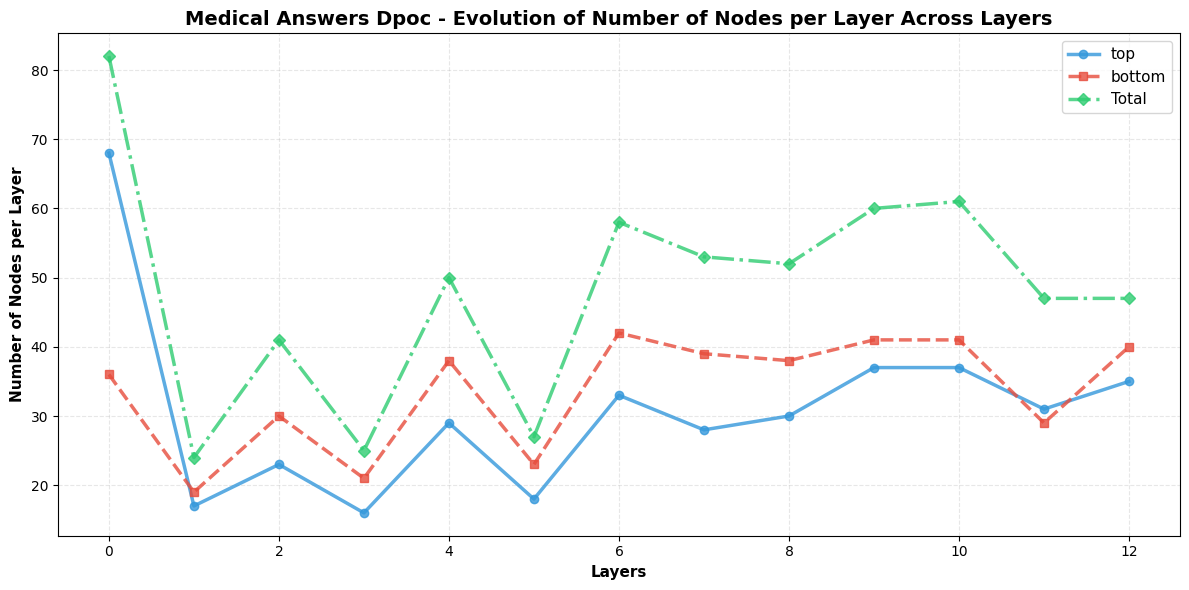

[50] Plotando medical_answers_dpoc para (bert-base-portuguese-cased)...


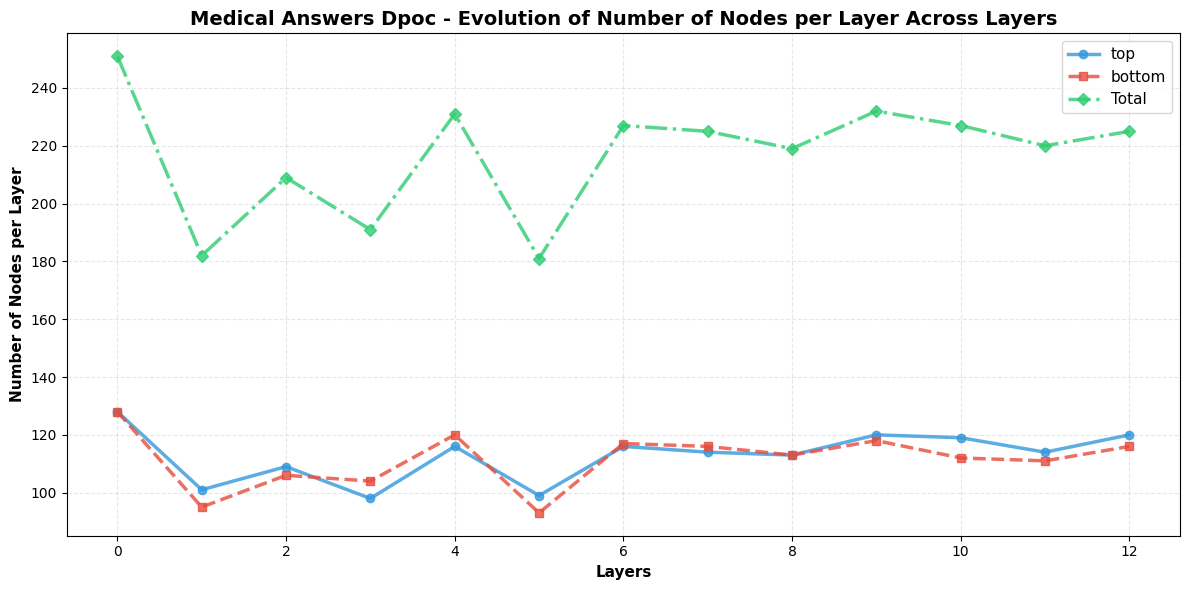

[10] Plotando medical_answers_dpoc para (bert-base-multilingual-cased)...


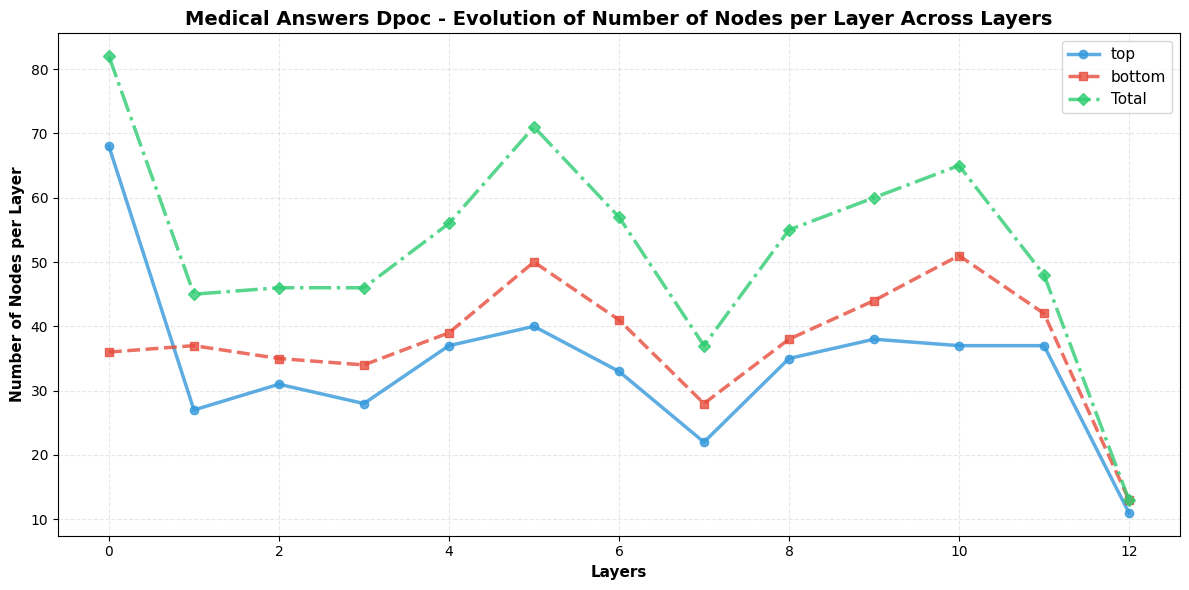

[50] Plotando medical_answers_dpoc para (bert-base-multilingual-cased)...


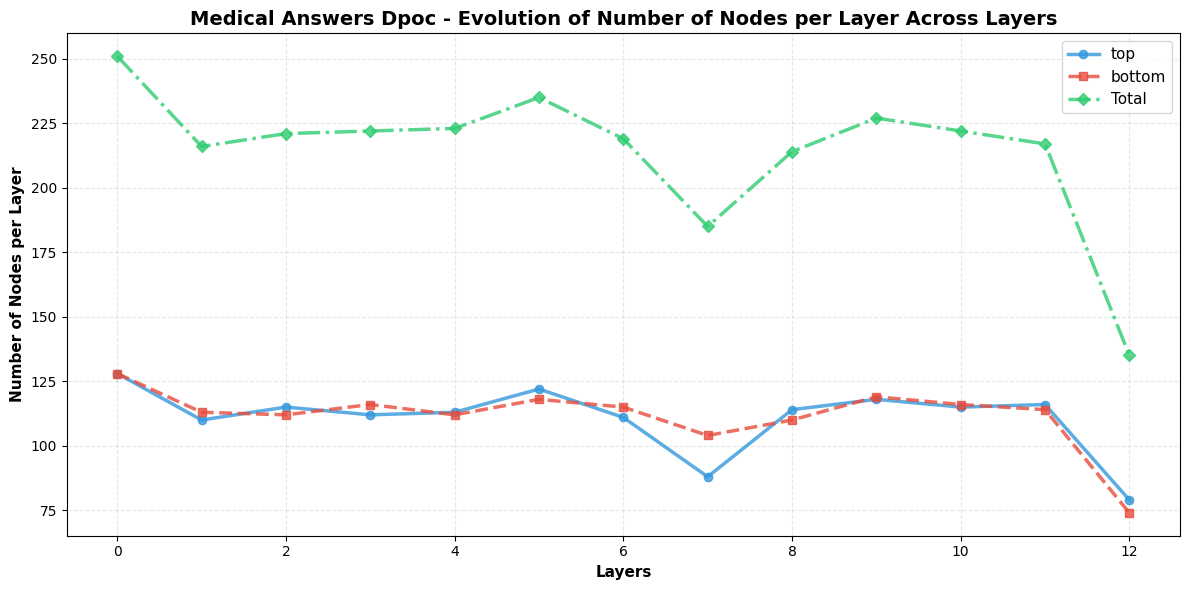

[10] Plotando medical_answers_dpoc para (biobertpt-all)...


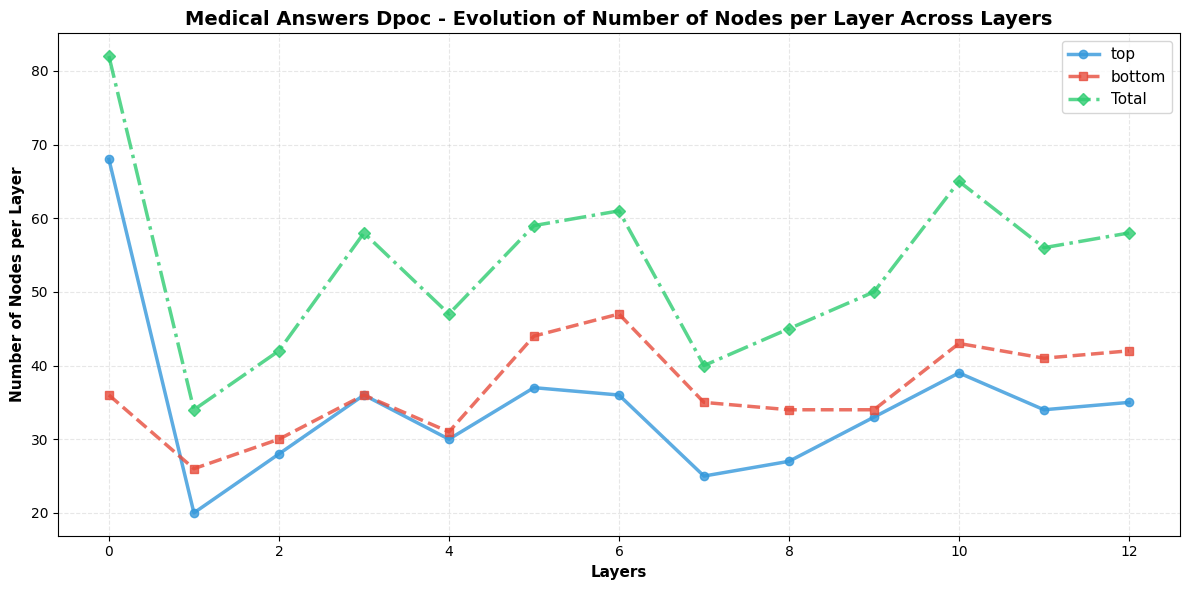

[50] Plotando medical_answers_dpoc para (biobertpt-all)...


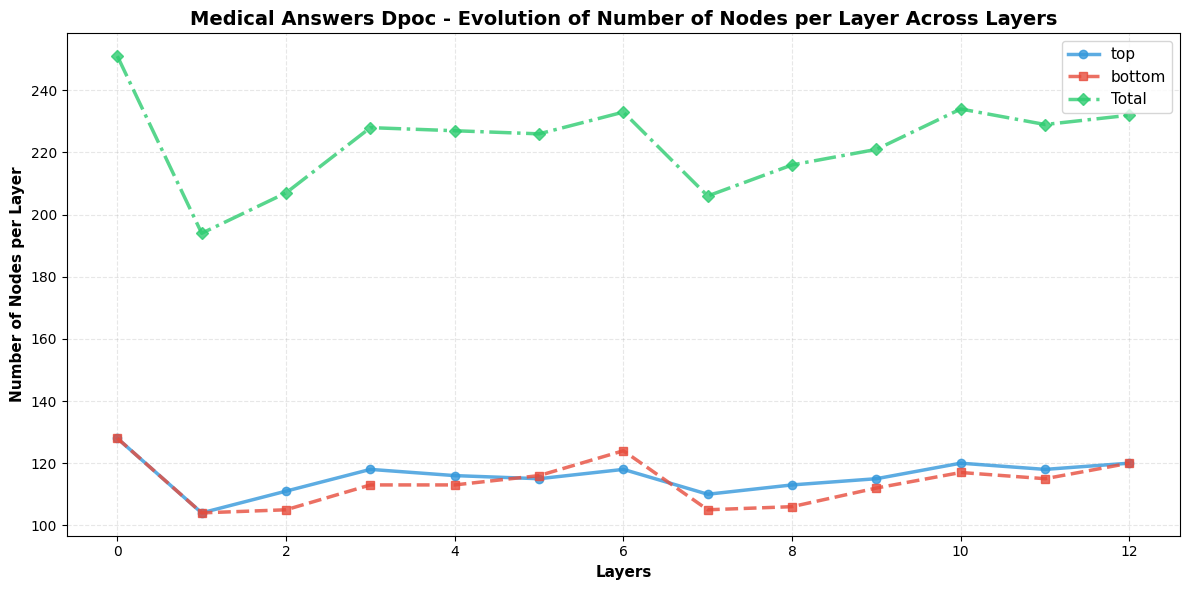

[10] Plotando medical_answers_dpoc para (bert-large-portuguese-cased)...


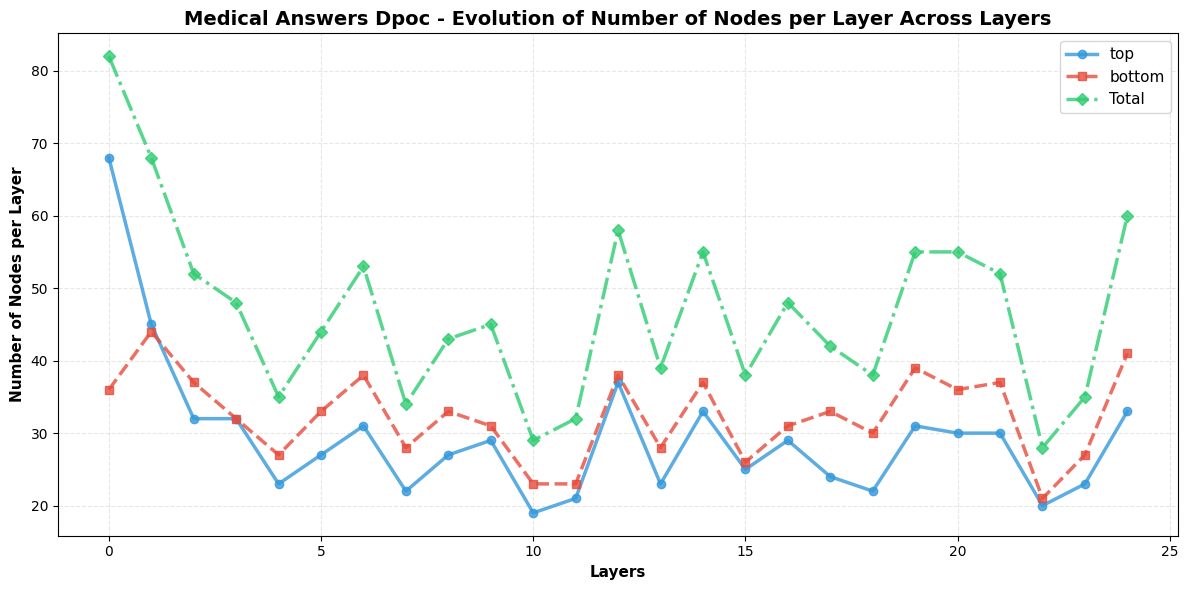

[50] Plotando medical_answers_dpoc para (bert-large-portuguese-cased)...


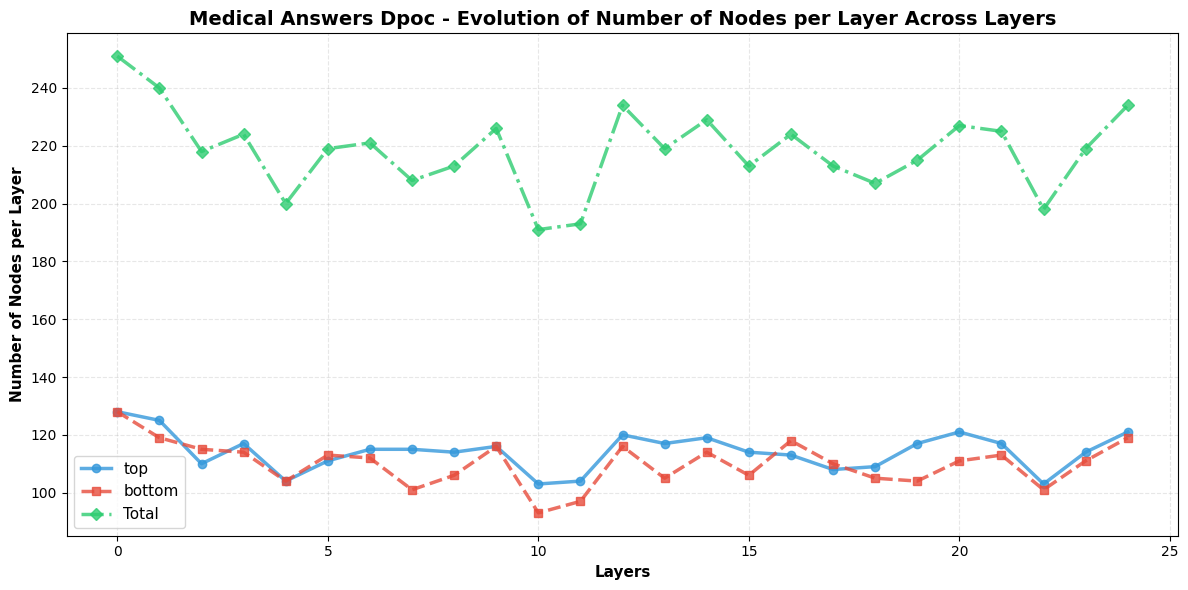

[10] Plotando medical_answers_dpoc para (distilbert-base-multilingual-cased)...


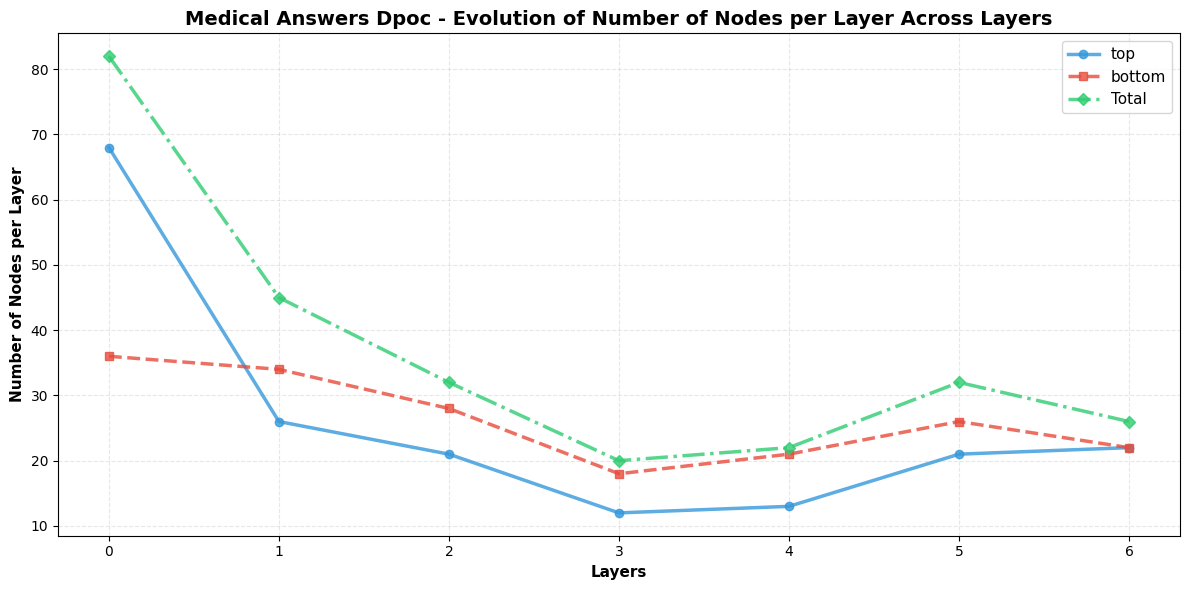

[50] Plotando medical_answers_dpoc para (distilbert-base-multilingual-cased)...


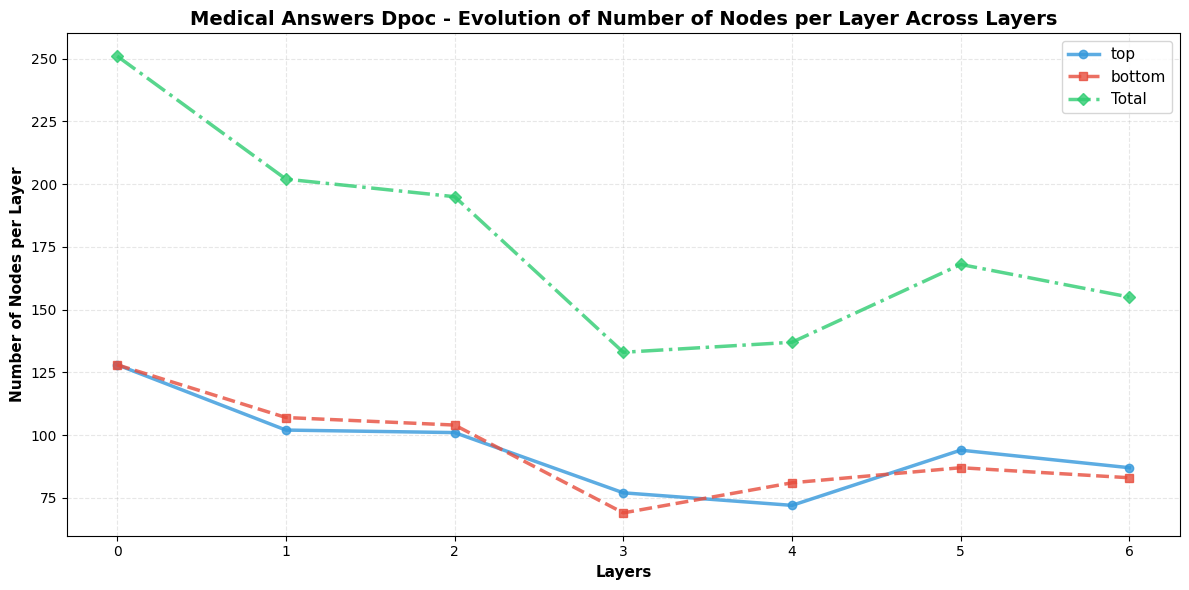

[10] Plotando medical_answers_iam para (bert-base-portuguese-cased)...


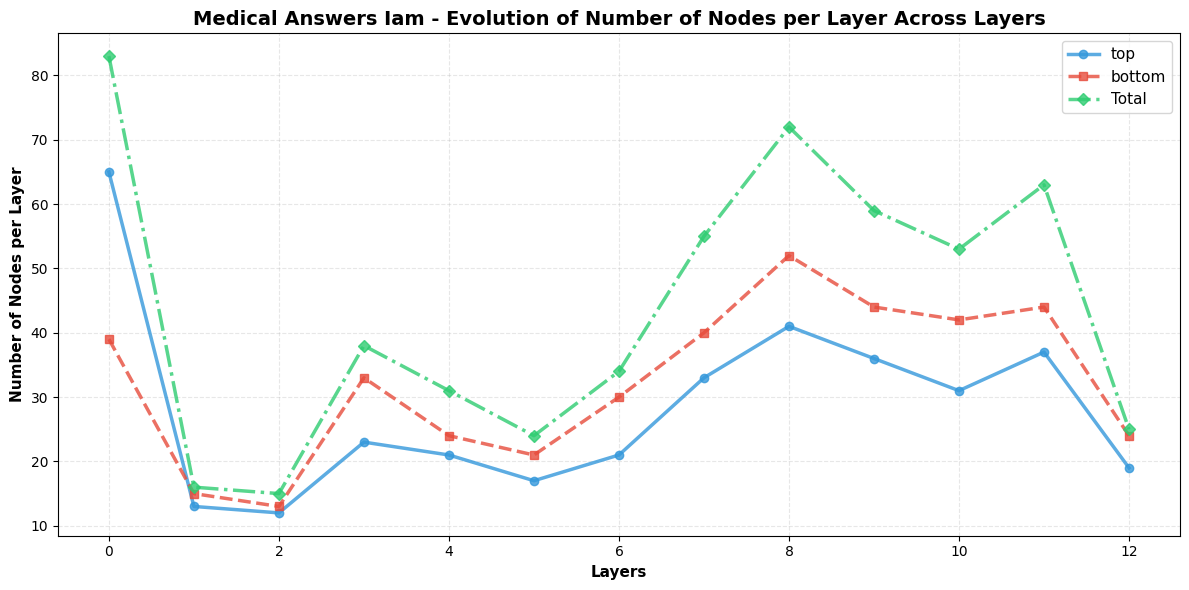

[50] Plotando medical_answers_iam para (bert-base-portuguese-cased)...


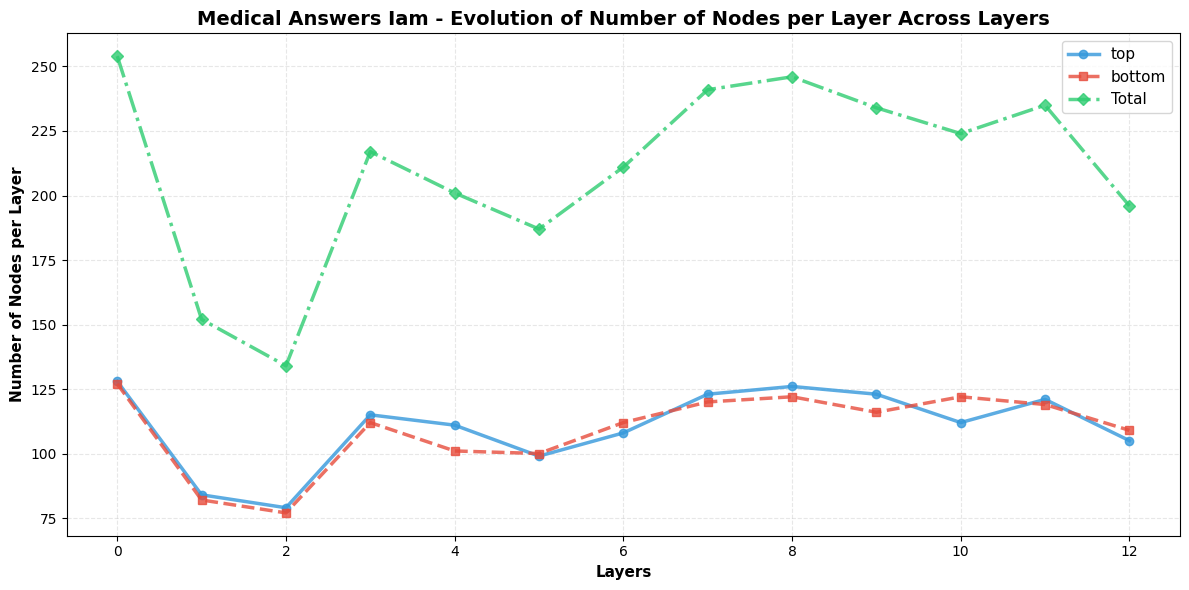

[10] Plotando medical_answers_iam para (bert-base-multilingual-cased)...


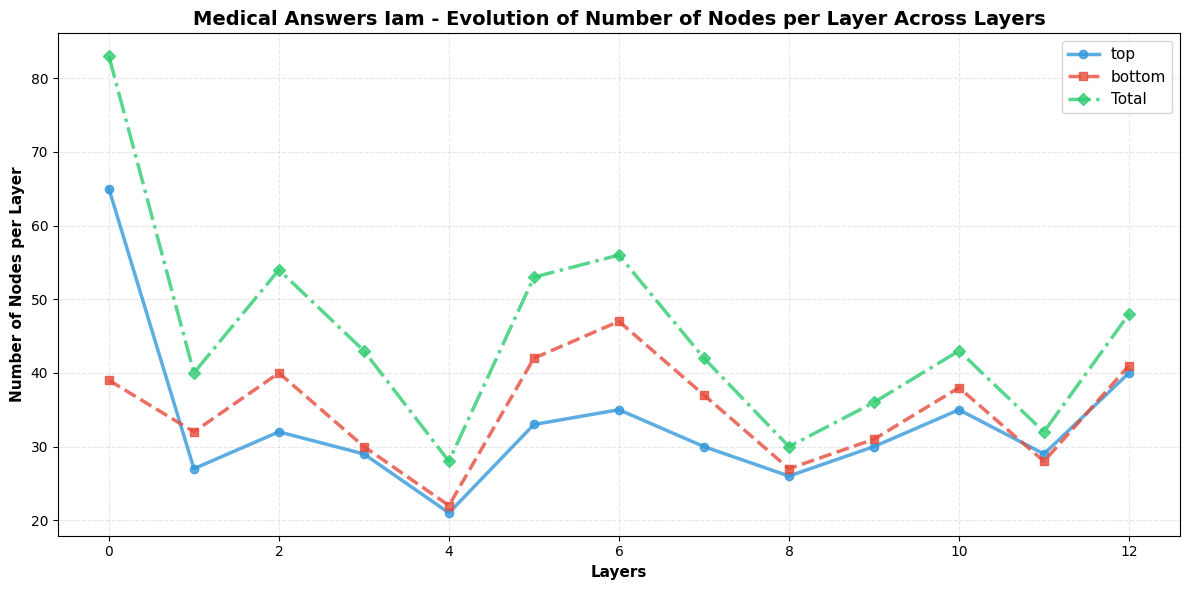

[50] Plotando medical_answers_iam para (bert-base-multilingual-cased)...


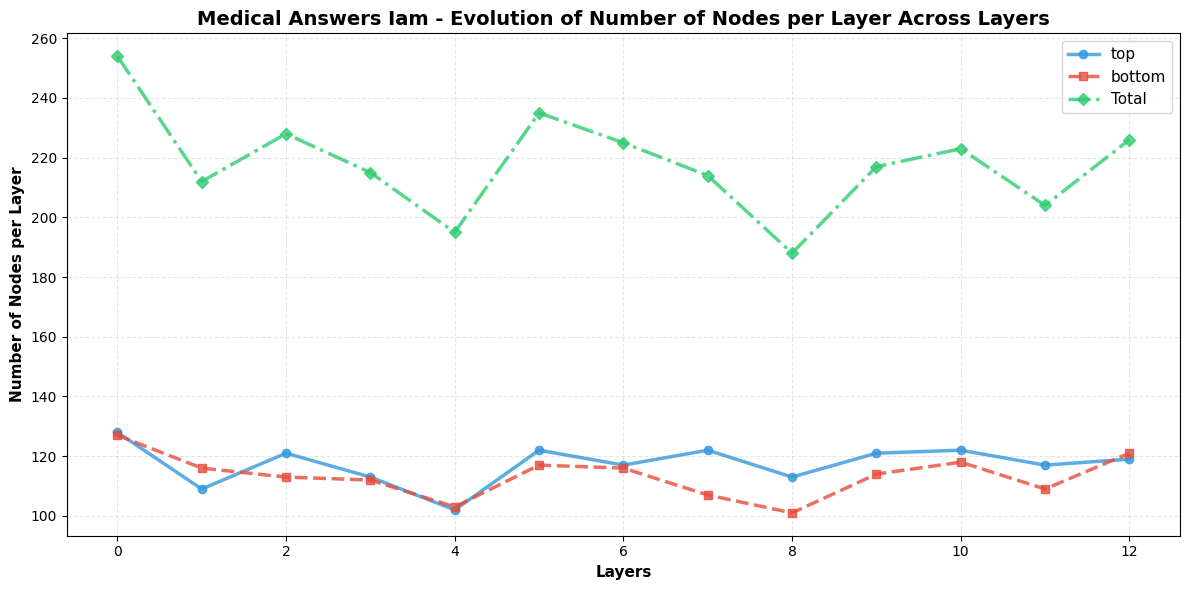

[10] Plotando medical_answers_iam para (biobertpt-all)...


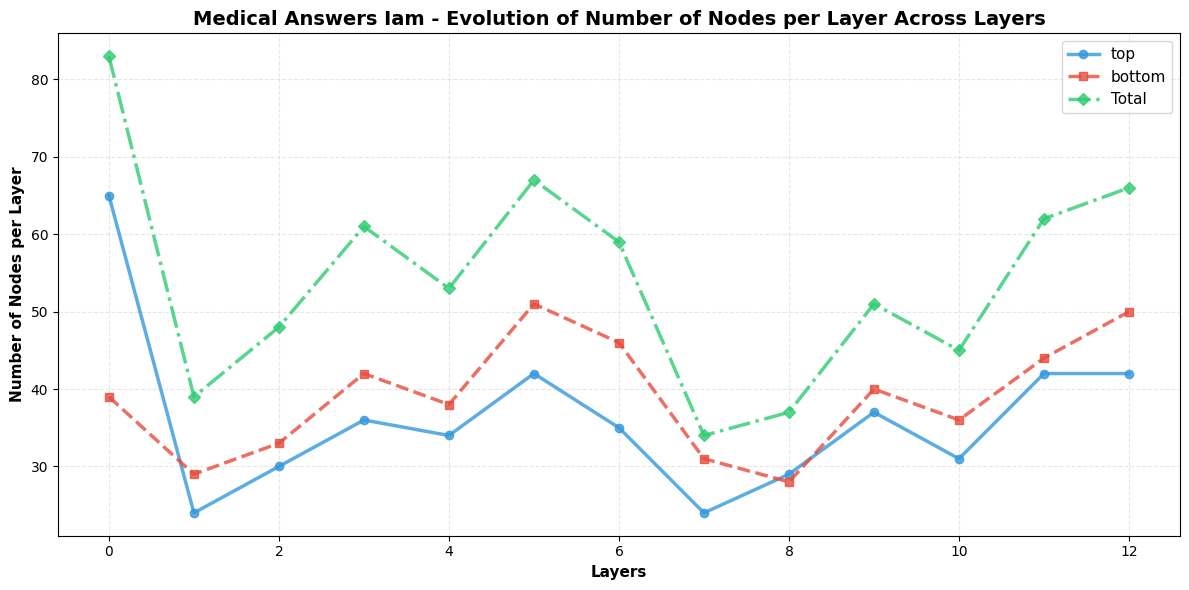

[50] Plotando medical_answers_iam para (biobertpt-all)...


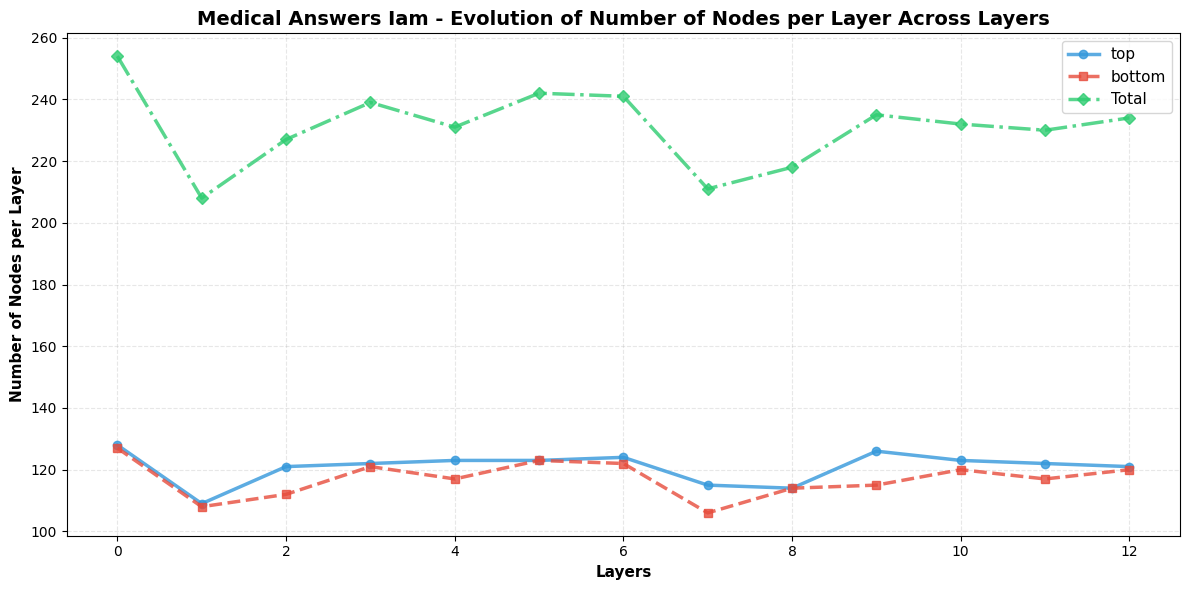

[10] Plotando medical_answers_iam para (bert-large-portuguese-cased)...


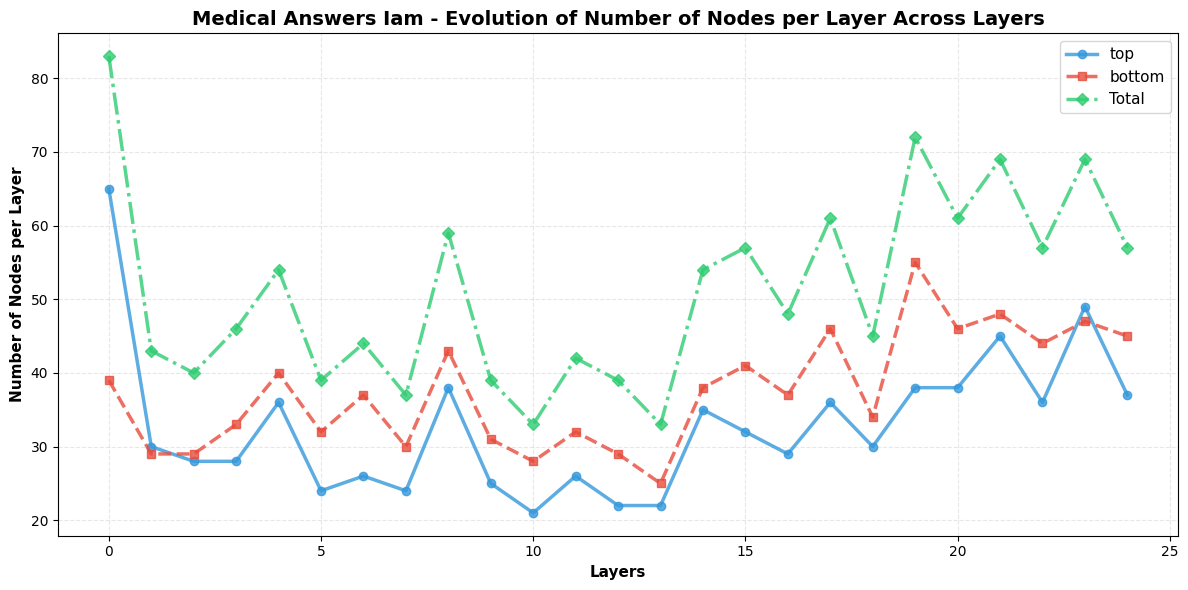

[50] Plotando medical_answers_iam para (bert-large-portuguese-cased)...


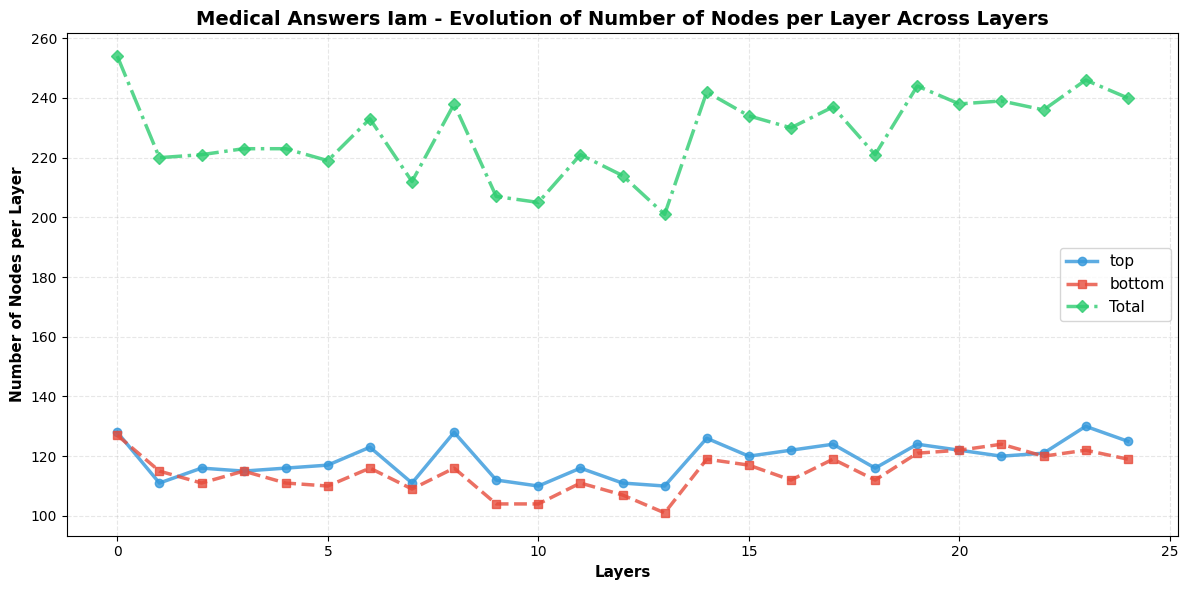

[10] Plotando medical_answers_iam para (distilbert-base-multilingual-cased)...


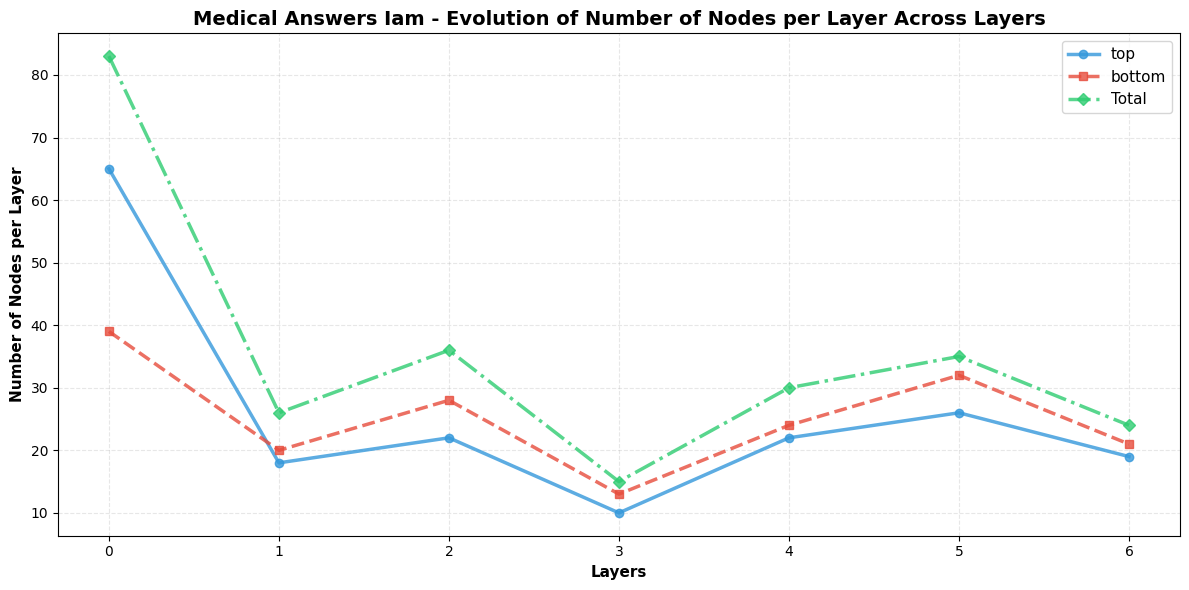

[50] Plotando medical_answers_iam para (distilbert-base-multilingual-cased)...


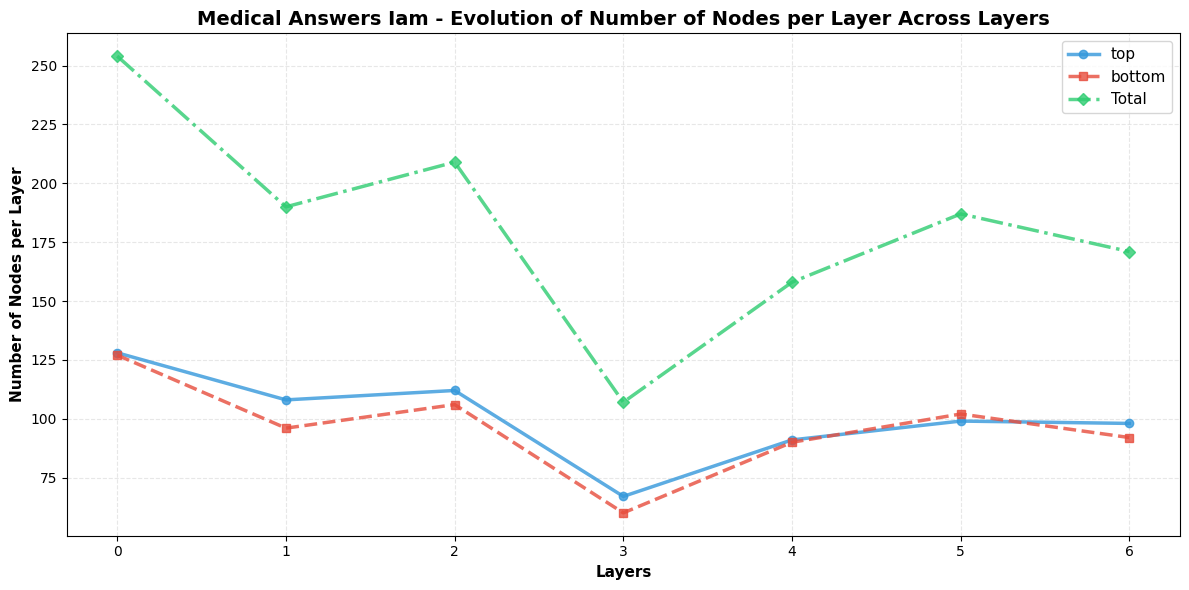

[10] Plotando odd_man_out_2_000 para (bert-base-uncased)...


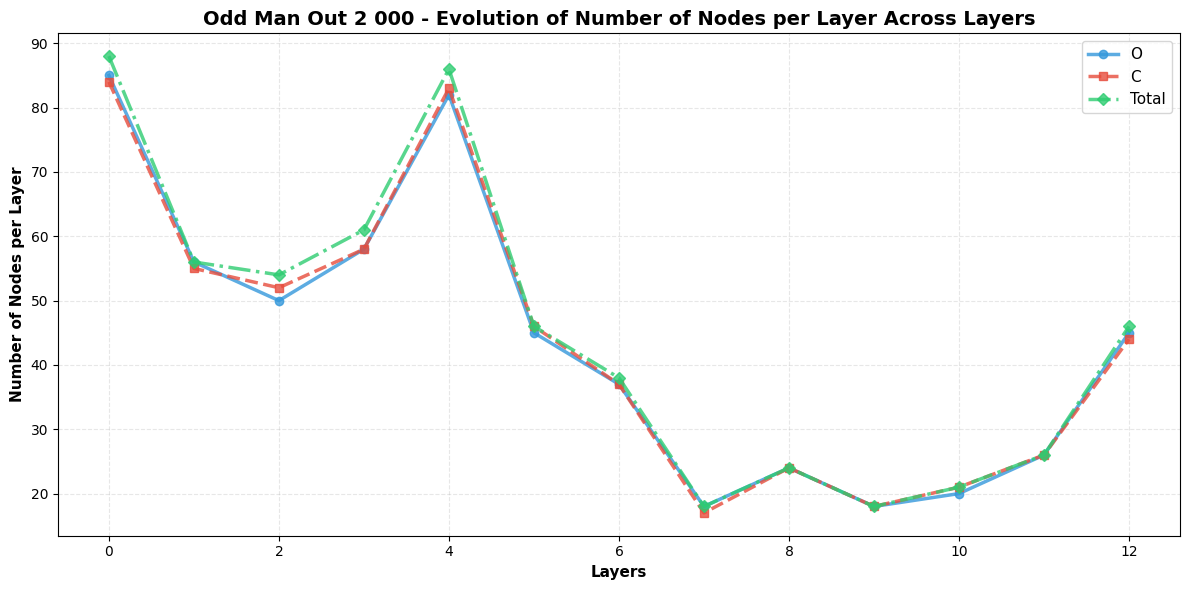

[50] Plotando odd_man_out_2_000 para (bert-base-uncased)...


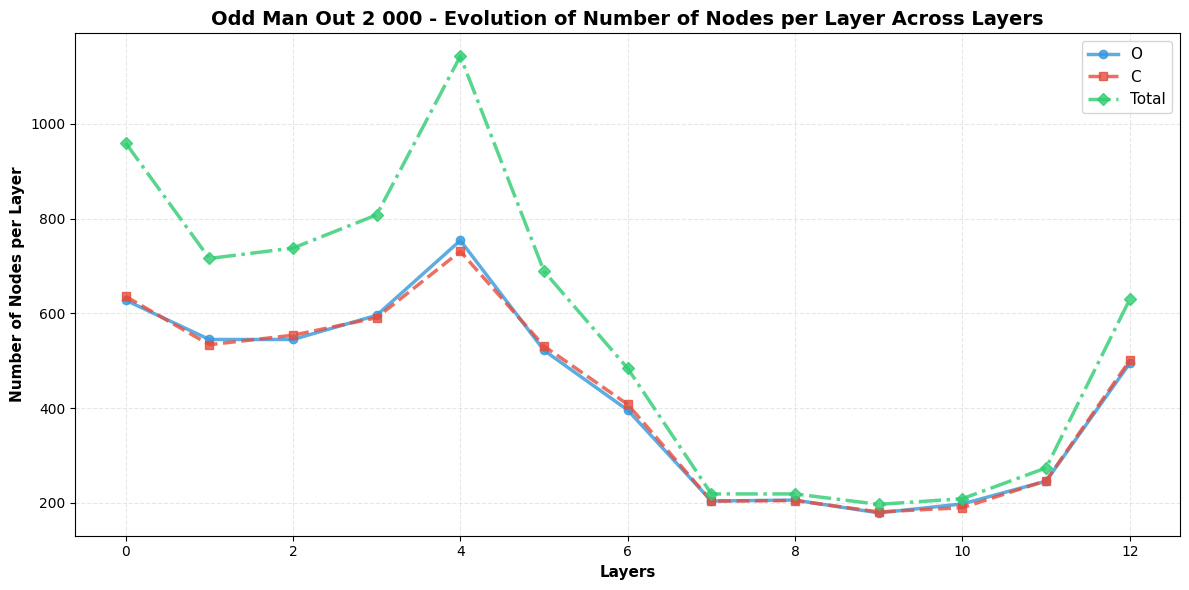

[10] Plotando odd_man_out_2_000 para (bert-large-uncased)...


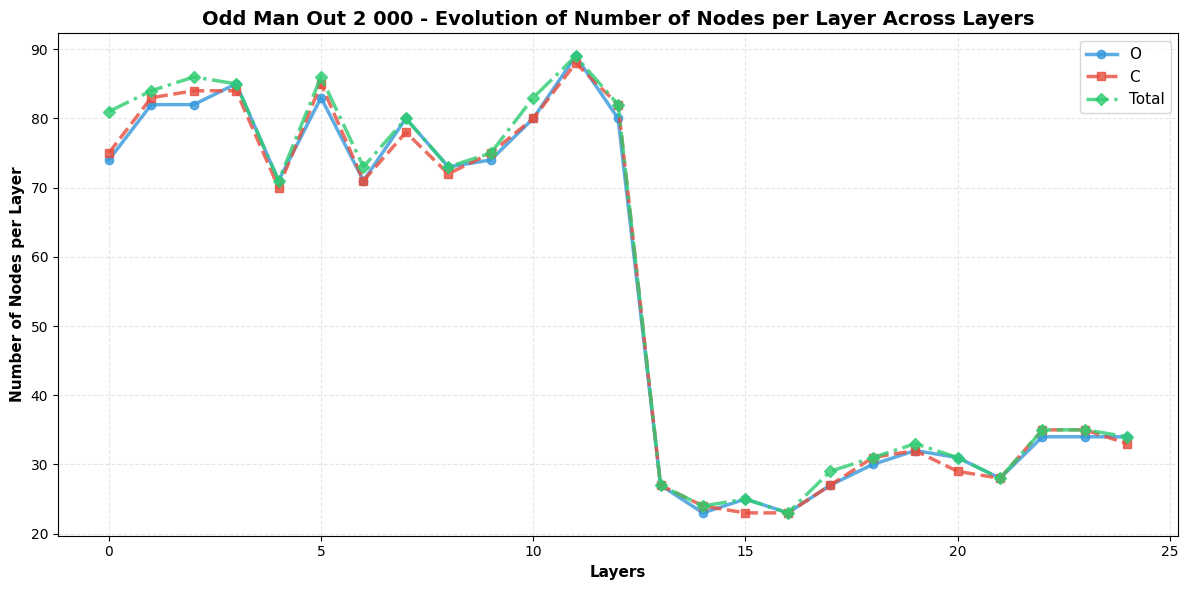

[50] Plotando odd_man_out_2_000 para (bert-large-uncased)...


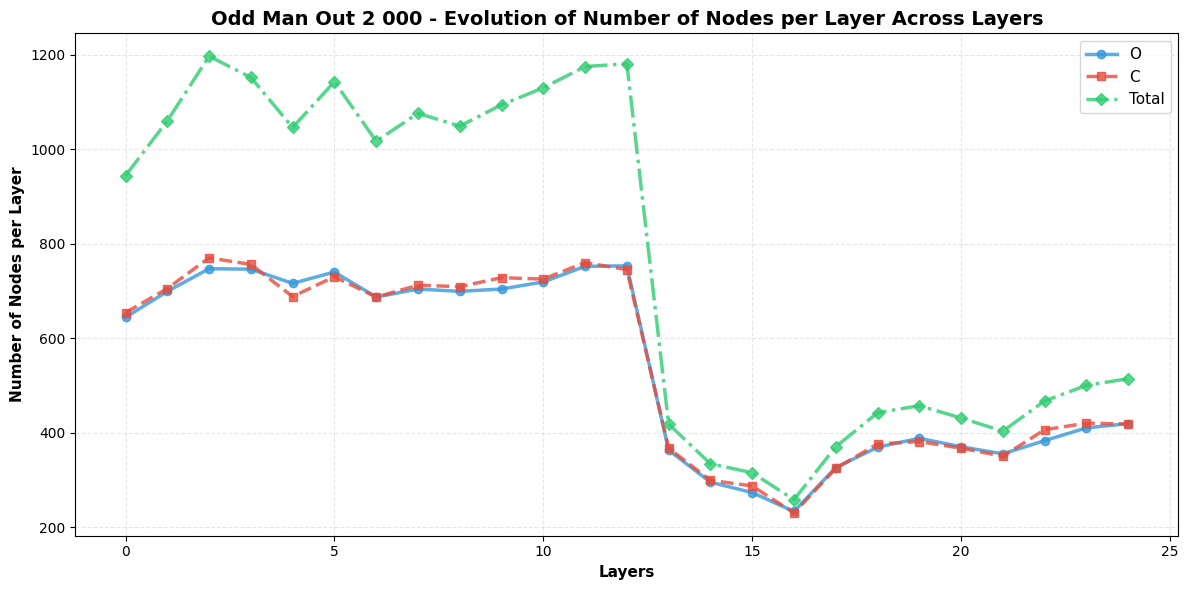

In [13]:
import os

def plot_csv_layer_evolution_generalized(dataset_name, labels_list, metric_name, task, model, grid_size, base_path=PROCESSED_DATASET_PATH, ylabel=None):
    """
    Plota a evolução de uma métrica através das camadas para um dataset específico.
    
    Args:
        dataset_name: Nome do dataset (ex: 'bigram_shift', 'odd_man_out')
        labels_list: Lista de labels para o dataset (ex: ['I', 'O', 'total'])
        metric_name: Nome da métrica a plotar
        base_path: Caminho base dos arquivos CSV
        ylabel: Label customizado para o eixo Y (opcional)
    """
    plt.figure(figsize=(12, 6))
    
    # Cores automáticas baseadas no índice (exceto 'total' que sempre é verde)
    color_palette = ["#3498db", "#e74c3c", "#f39c12", "#9b59b6", "#1abc9c", "#34495e"]
    
    found_any_data = False
    
    print(f"[{grid_size}] Plotando {task} para ({model.split('/')[-1]})...")

    for idx, label in enumerate(labels_list):
        file_path = f"data/processed/{grid_size}/{task}_metrics_per_layer_{model.split('/')[-1]}_{label}.csv"
        
        if os.path.exists(file_path):
            df_metrics = pd.read_csv(file_path)
            
            if metric_name in df_metrics.columns:
                # Definir cor e estilo
                if label == "total":
                    color = "#2ecc71"
                    linestyle = "-."
                    marker = "D"
                    style_label = "Total"
                else:
                    color = color_palette[idx % len(color_palette)]
                    linestyle = "-" if idx % 2 == 0 else "--"
                    marker = "o" if idx % 2 == 0 else "s"
                    style_label = label
                
                plt.plot(
                    df_metrics['layer'],
                    df_metrics[metric_name],
                    label=style_label,
                    color=color,
                    linestyle=linestyle,
                    linewidth=2.5,
                    marker=marker,
                    markersize=6,
                    alpha=0.8
                )
                found_any_data = True
        else:
            print(f"⚠ Arquivo não encontrado: {file_path}")
    
    if not found_any_data:
        plt.close()
        print(f"❌ Nenhum arquivo encontrado para o dataset: {dataset_name}")
        return

    # Configurações de labels e título
    if ylabel is None:
        ylabel = metric_name.replace('_', ' ').title()
    
    plt.title(f"{dataset_name.replace('_', ' ').title()} - Evolution of {ylabel} Across Layers", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Layers", fontweight='bold', fontsize=11)
    plt.ylabel(ylabel, fontweight='bold', fontsize=11)
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


# ===== Exemplo de uso =====
# labels = {
#    "bigram_shift": ['I', 'O', 'total'],
#    "odd_man_out": ["C", "O", "total"],
#    "sentence_length": ["0", "1", "2", "3", "4", "5", "total"]
# }.

metric_labels = {
    "num_nodes_per_layer": "Number of Nodes per Layer",
    # "edge_num_edges_per_layer": "Number of Edges per Layer",
    # "degree_per_layer": "Mean Degree per Layer",
    # "node_betweenness_per_layer": "Node Betweenness per Layer",
    # "node_strength_per_layer": "Node Strength per Layer",
    # "average_neighbor_degree": "Average Neighbor Degree",
    # "edge_edge_betweenness_per_layer": "Edge Betweenness per Layer"
}

# Plotar para todos os datasets
for task, info in exps_dict.items():
    for model in info["models"]:
        for grid_size in GRID_SIZES:

            # Detectar métricas disponíveis
            sample_file = f"data/processed/{grid_size}/{task}_metrics_per_layer_{model.split('/')[-1]}_{label}.csv"
            if os.path.exists(sample_file):
                df_sample = pd.read_csv(sample_file)
                metrics_to_plot = [col for col in df_sample.columns if col not in ['layer', 'layer_description']]
                
                # for metric_name in metrics_to_plot:
                for metric_name in ["num_nodes_per_layer"]:
                    ylabel = metric_labels.get(metric_name, metric_name.replace('_', ' ').title())
                    plot_csv_layer_evolution_generalized(task, [*info["labels"], "total"], metric_name, ylabel=ylabel, task=task, model=model, grid_size=grid_size)

# Inversion Study

Existe uma tendencia para quase todos os modelos do vermelho apresentar valores superiores para grid de 10 e apresentar valores inferiores para um grid de 50. 


* Gridsize não tem nada haver com a redução de dimensionalidade, é usado depois...
- como isso influencia o grafo depois?

Caso de estudo:  
medical_answers_dpoc para (bert-large-portuguese-cased)

10:
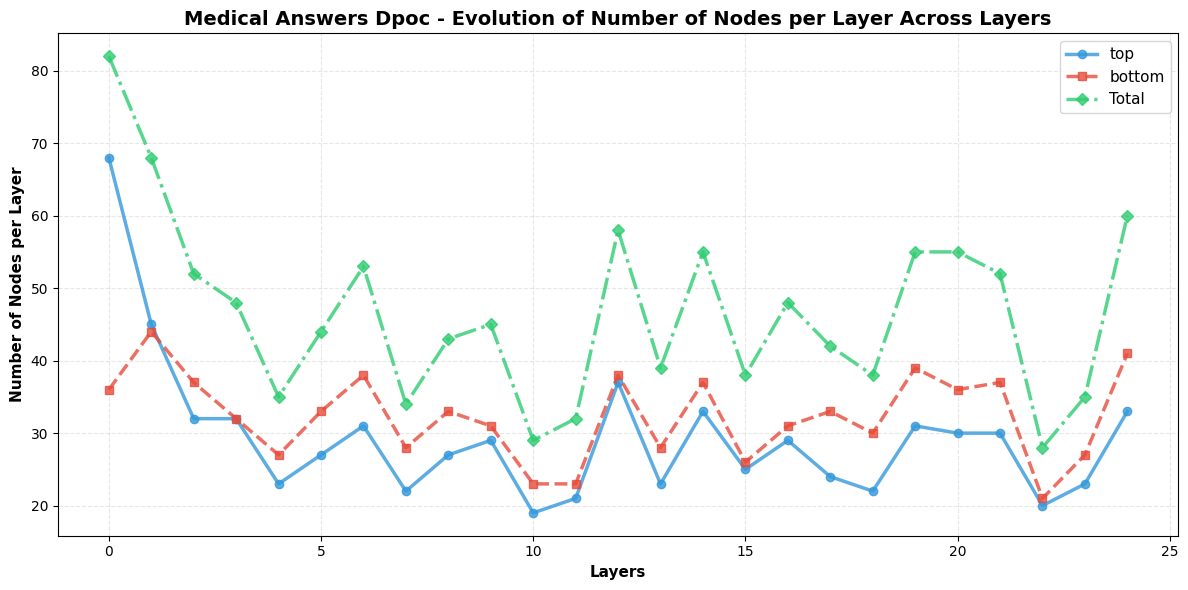

50:
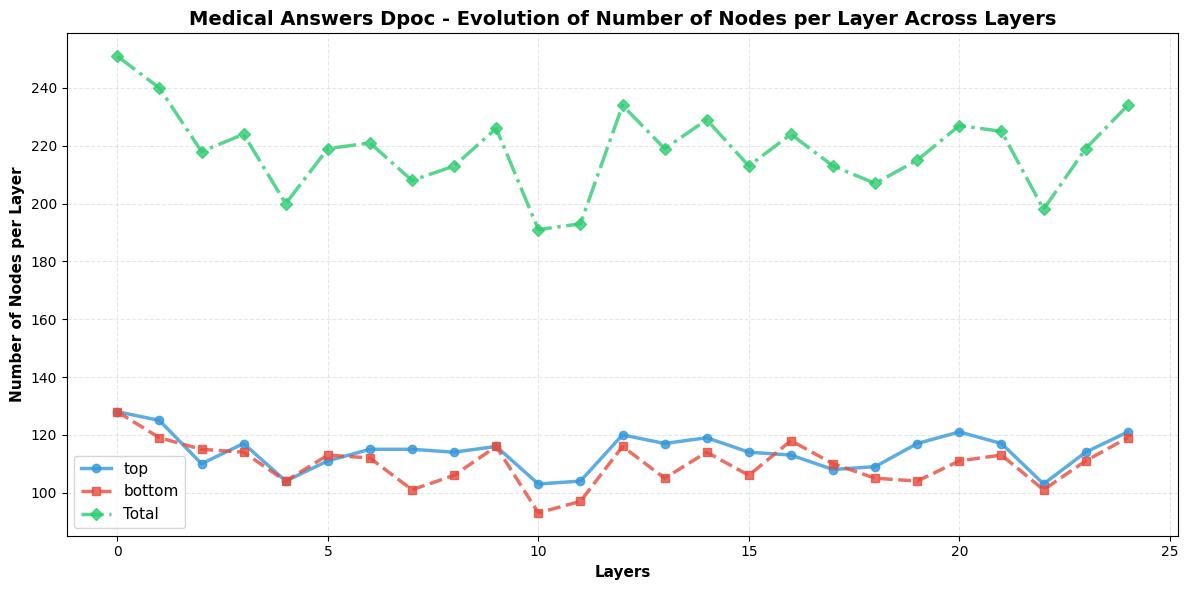


In [6]:
model = "neuralmind/bert-large-portuguese-cased"
layers = [6, 7, 10, 11, 12, 13, 14, 15, 18, 19, 20]


In [7]:
data = load_from_disk("../datasets/medical_answers/dpoc_hf_dataset")

# gridsize 10 
umap_10 = UMAP(n_components=2, random_state=42, gridsize=10)
llm_mri_10 = ActivationAreas(
    model=model, device="cpu", dataset=data, reduction_method=umap_10
)
llm_mri_10.process_activation_areas()

for label in ["top", "bottom"]:
    current_graph = llm_mri_10.get_graph(label)
    nx.write_gexf(
        current_graph, f"data/graphs/g_10_{label}.gexf"
    )

total_graph = llm_mri_10.get_graph(["top", "bottom"])
nx.write_gexf(total_graph, f"data/graphs//g_10_total.gexf")


# gridsize 50
umap_50 = UMAP(n_components=2, random_state=42, gridsize=50)
llm_mri_50 = ActivationAreas(
    model=model, device="cpu", dataset=data, reduction_method=umap_50
)
llm_mri_50.process_activation_areas()  
for label in ["top", "bottom"]:
    current_graph = llm_mri_50.get_graph(label)
    nx.write_gexf(
        current_graph, f"data/graphs/g_50_{label}.gexf"
    )

total_graph = llm_mri_50.get_graph(["top", "bottom"])
nx.write_gexf(total_graph, f"data/graphs//g_50_total.gexf")


Map:   0%|          | 0/258 [00:00<?, ? examples/s]

/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/u

Map:   0%|          | 0/258 [00:00<?, ? examples/s]

/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/u

In [13]:
grid_df = llm_mri_10.graph_class.get_grid_df(layer=6, category_name="top")
print(len(grid_df))
print(grid_df.info())


8
<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 7 to 0
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   2       8 non-null      int64
 1   3       8 non-null      int64
 2   4       8 non-null      int64
 3   5       8 non-null      int64
 4   6       8 non-null      int64
 5   7       8 non-null      int64
 6   8       8 non-null      int64
 7   9       8 non-null      int64
dtypes: int64(8)
memory usage: 576.0 bytes
None


In [14]:
grid50_df = llm_mri_50.graph_class.get_grid_df(layer=6, category_name="top")
print(len(grid50_df))
print(grid50_df.info())

35
<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 38 to 0
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   13      35 non-null     int64
 1   18      35 non-null     int64
 2   20      35 non-null     int64
 3   23      35 non-null     int64
 4   24      35 non-null     int64
 5   25      35 non-null     int64
 6   26      35 non-null     int64
 7   27      35 non-null     int64
 8   28      35 non-null     int64
 9   29      35 non-null     int64
 10  30      35 non-null     int64
 11  32      35 non-null     int64
 12  33      35 non-null     int64
 13  34      35 non-null     int64
 14  35      35 non-null     int64
 15  36      35 non-null     int64
 16  37      35 non-null     int64
 17  38      35 non-null     int64
 18  39      35 non-null     int64
 19  40      35 non-null     int64
 20  41      35 non-null     int64
 21  42      35 non-null     int64
 22  43      35 non-null     int64
 23  44      35 non-null

In this heatmap, each cell represents the number of activations that the specific reduced region on a determined layer received for the provided corpus.

 ============== Layer 7 - top ==============
Grid 10:


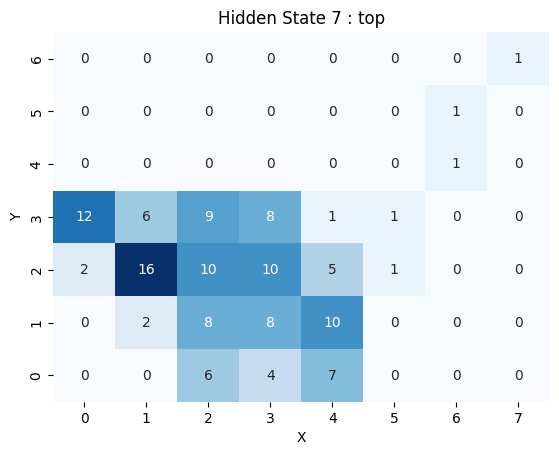

Grid 10 - Num Nodes:
22
---------------------
Grid 50:


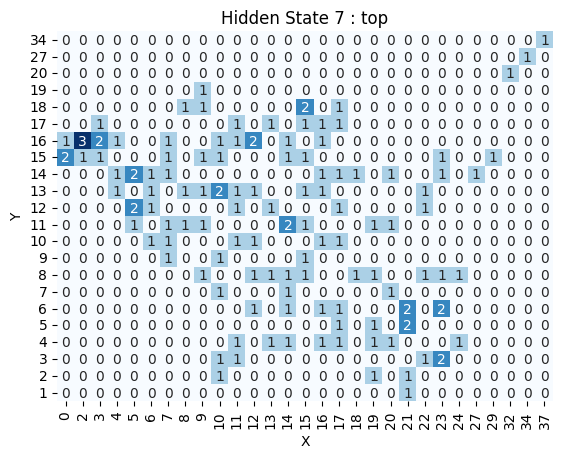

Grid 50 - Num Nodes:
115
 ============== Layer 7 - bottom ==============
Grid 10:


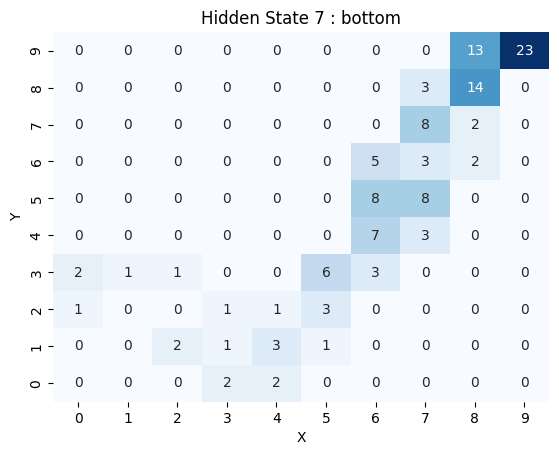

Grid 10 - Num Nodes:
28
---------------------
Grid 50:


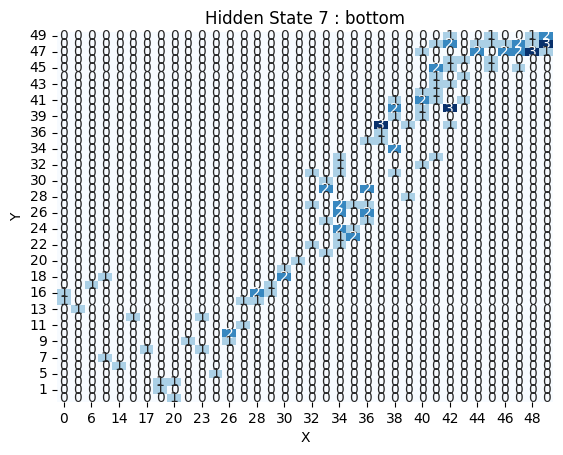

Grid 50 - Num Nodes:
101


In [20]:
# layers = [6, 7, 10, 11, 12, 13, 14, 15, 18, 19, 20]
layers = [7]


graph_dict = {}
for grid_size in [10, 50]:
  for label in ["top", "bottom", "total"]:
    current_graph = nx.read_gexf(f"data/graphs/g_{grid_size}_{label}.gexf")
    if grid_size not in graph_dict:
        graph_dict[grid_size] = {}
    graph_dict[grid_size][label] = get_num_nodes_per_layer(current_graph)
    



for label in ["top", "bottom"]:
  for layer in layers:
    print(f" ============== Layer {layer} - {label} ==============")
   
    print("Grid 10:")
    fig = llm_mri_10.get_grid(layer=layer, category_name=label)
    plt.show(fig)
    print(f"Grid 10 - Num Nodes:")
    print(graph_dict[10][label][layer])

    print("---------------------")

    print("Grid 50:")
    fig50= llm_mri_50.get_grid(layer=layer, category_name=label)
    plt.show(fig50)
    print(f"Grid 50 - Num Nodes:")
    print(graph_dict[50][label][layer])


In [31]:
print(pd.Series(data["label"]).value_counts())

0    129
1    129
Name: count, dtype: int64
